Using device: mps


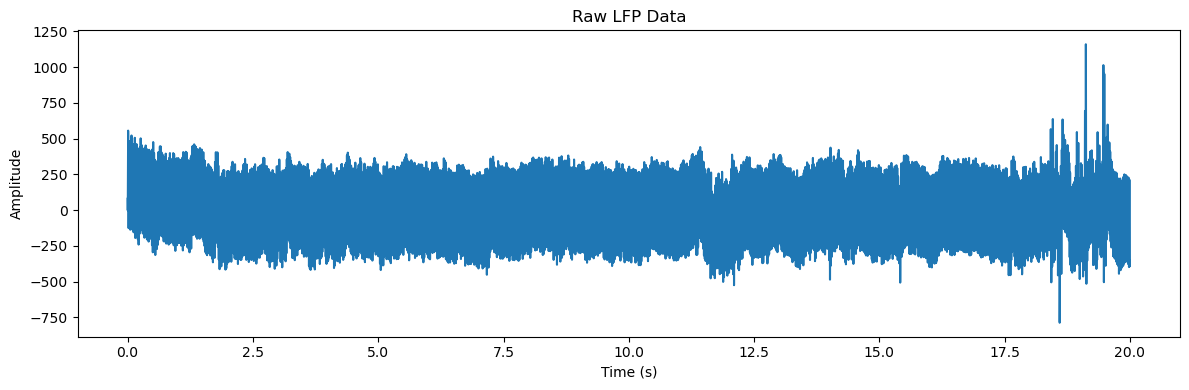

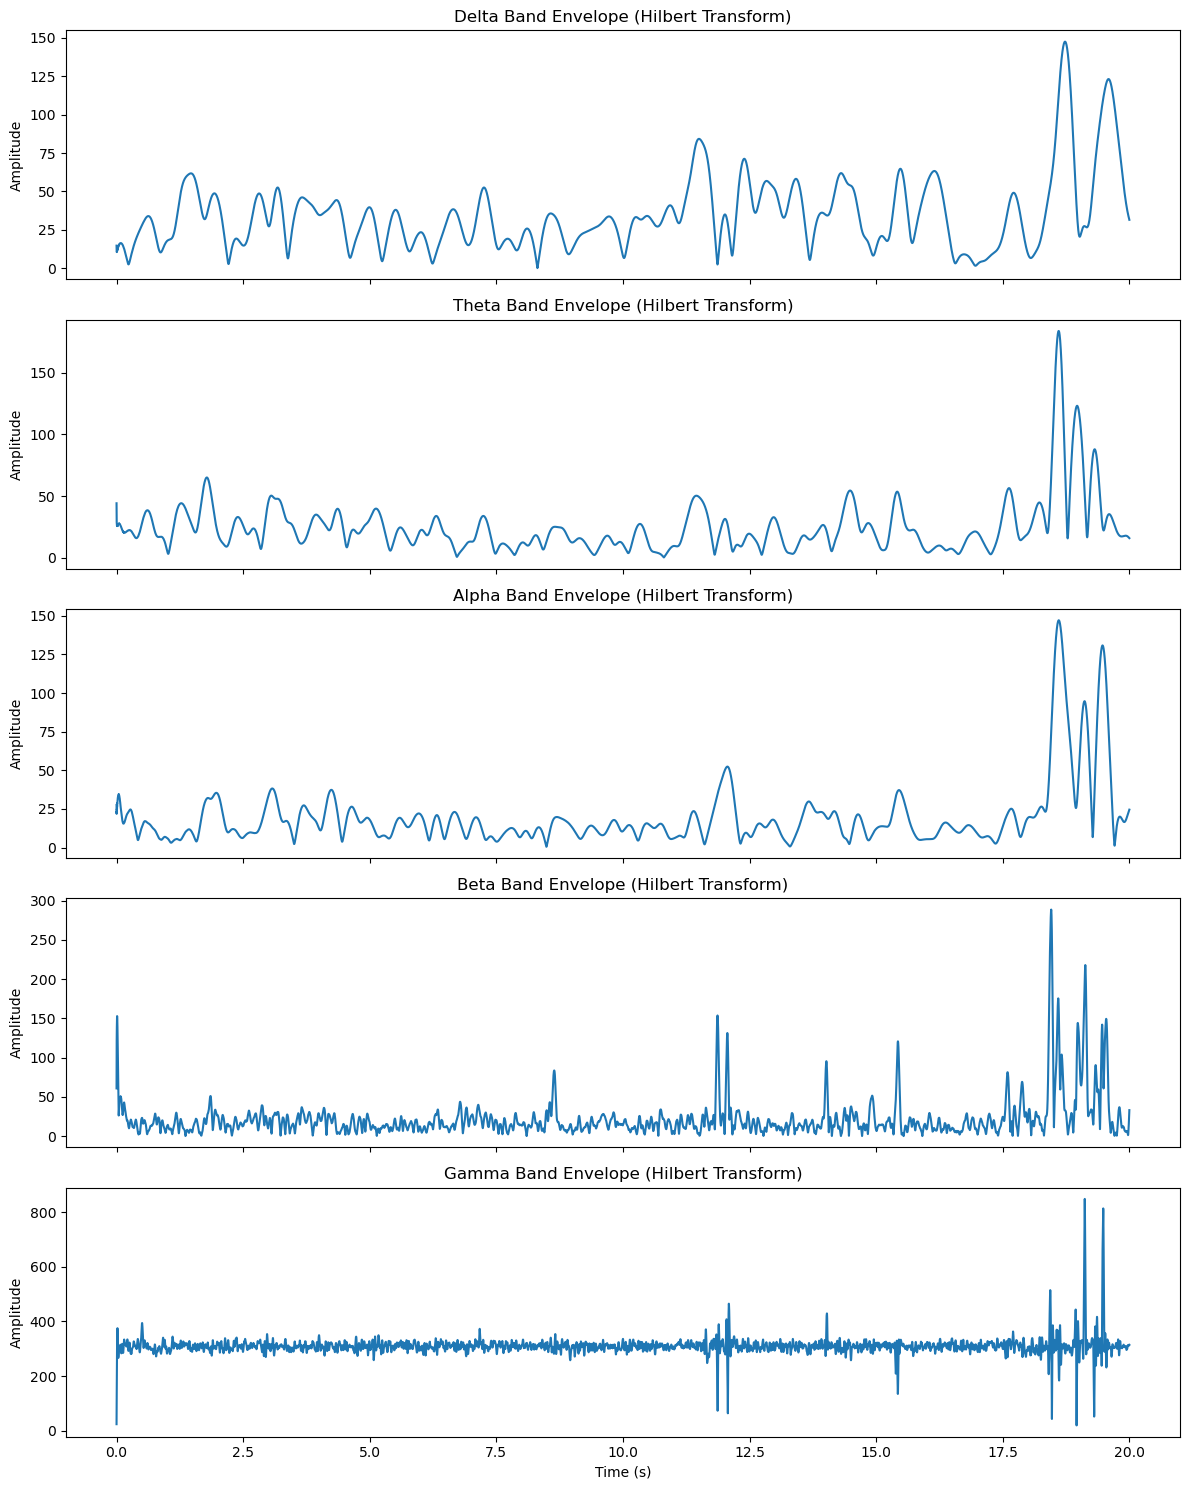

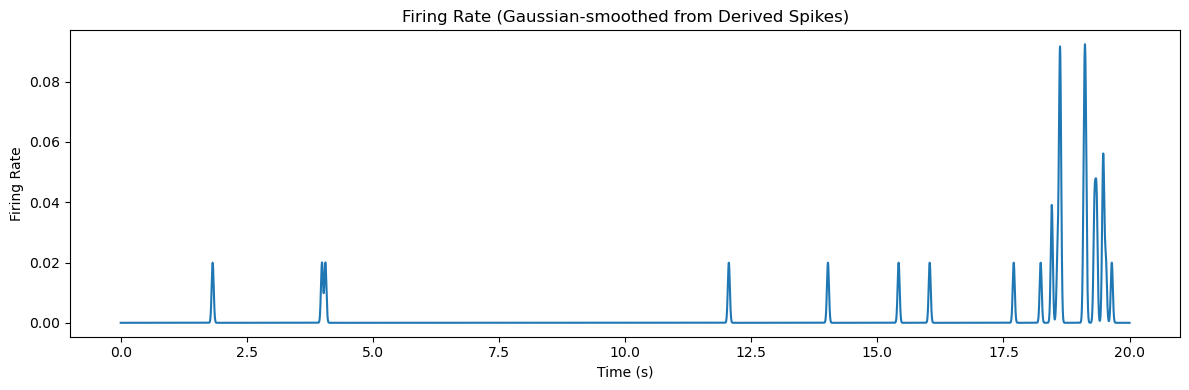

Epoch 1/30: Train Loss 0.0027618, Val Loss 0.0007362
Epoch 2/30: Train Loss 0.0009170, Val Loss 0.0002402
Epoch 3/30: Train Loss 0.0007587, Val Loss 0.0007878
Epoch 4/30: Train Loss 0.0009624, Val Loss 0.0006346
Epoch 5/30: Train Loss 0.0007431, Val Loss 0.0002329
Epoch 6/30: Train Loss 0.0005071, Val Loss 0.0001051
Epoch 7/30: Train Loss 0.0004684, Val Loss 0.0001850
Epoch 8/30: Train Loss 0.0004992, Val Loss 0.0002293
Epoch 9/30: Train Loss 0.0004720, Val Loss 0.0001743
Epoch 10/30: Train Loss 0.0003999, Val Loss 0.0001002
Epoch 11/30: Train Loss 0.0003465, Val Loss 0.0000654
Epoch 12/30: Train Loss 0.0003266, Val Loss 0.0000575
Epoch 13/30: Train Loss 0.0003205, Val Loss 0.0000537
Epoch 14/30: Train Loss 0.0003000, Val Loss 0.0000560
Epoch 15/30: Train Loss 0.0002739, Val Loss 0.0000677
Epoch 16/30: Train Loss 0.0002542, Val Loss 0.0000802
Epoch 17/30: Train Loss 0.0002447, Val Loss 0.0000842
Epoch 18/30: Train Loss 0.0002366, Val Loss 0.0000763
Epoch 19/30: Train Loss 0.0002279, Va

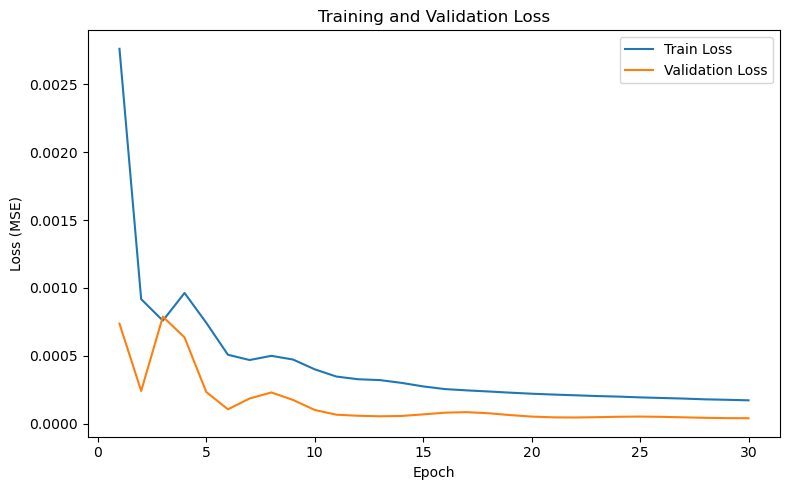

Test MSE Loss: 0.0000471
Percent NMSE: 69.78%
Continuous windows shape: (18001, 2000, 5)
Predictions shape: (18001, 2000)


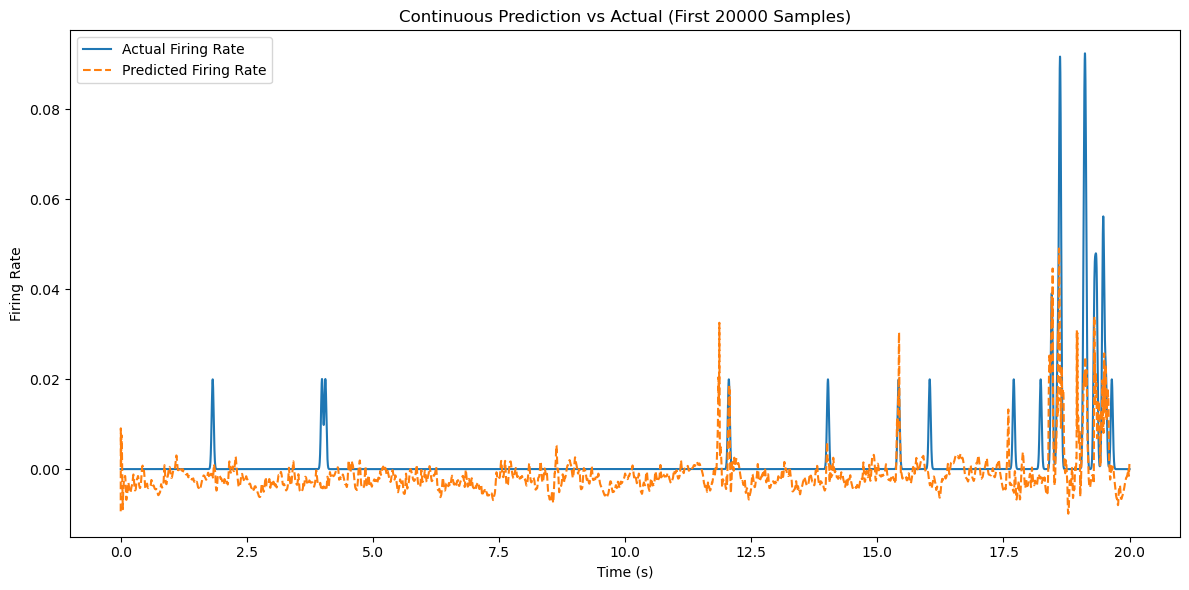

In [ ]:
import numpy as np
import scipy.io
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ===========================
# Device configuration: use MPS on Mac if available
# ===========================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ===========================
# 1. Load MATLAB data (only LFP is used now)
# ===========================
mat = scipy.io.loadmat('ns2eeg_202014.mat')
microwire = mat['ns2_sEEG'][104, :].squeeze()

# Convert LFP data to float (if originally int16)
microwire = microwire.astype(np.float64)

# Define sampling frequency (Hz)
fs = 1000.0

# ===========================
# 2. Plot raw LFP data (first 20000 samples)
# ===========================
segment = slice(0, 20000)  # first 20000 samples for visualization
time_vec = np.arange(20000) / fs

plt.figure(figsize=(12, 4))
plt.plot(time_vec, microwire[segment])
plt.title("Raw LFP Data")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# ===========================
# 3. Process LFP into EEG bands with flexibility
# ===========================
all_eeg_bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta':  (12, 30),
    'gamma': (30, 100)
}
selected_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

def bandpass_filter(data, lowcut, highcut, fs, order=3):
    nyq  = 0.5 * fs
    low  = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def get_band_envelopes(signal, fs, bands_dict, selected_bands):
    filtered_signals = {}
    for band in selected_bands:
        low, high = bands_dict[band]
        filtered = bandpass_filter(signal, low, high, fs)
        analytic_signal = hilbert(filtered)
        envelope = np.abs(analytic_signal)
        filtered_signals[band] = envelope
    eeg_features = np.column_stack([filtered_signals[band] for band in selected_bands])
    return filtered_signals, eeg_features

filtered_signals, eeg_features = get_band_envelopes(microwire, fs, all_eeg_bands, selected_bands)

# ===========================
# 4. Plot EEG band envelopes for selected bands
# ===========================
num_bands = len(selected_bands)
fig, axes = plt.subplots(num_bands, 1, figsize=(12, 3 * num_bands), sharex=True)
for idx, band in enumerate(selected_bands):
    signal = filtered_signals[band]
    axes[idx].plot(time_vec, signal[segment])
    axes[idx].set_title(f'{band.capitalize()} Band Envelope (Hilbert Transform)')
    axes[idx].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# ===========================
# 5. Detect spikes from raw LFP and compute firing rate using Gaussian smoothing
# ===========================
def detect_spikes(lfp, fs, lowcut=100, highcut=300, threshold_multiplier=4, refractory_period=0.002):
    filtered = bandpass_filter(lfp, lowcut, highcut, fs, order=3)
    noise_std = np.median(np.abs(filtered)) / 0.6745
    threshold = threshold_multiplier * noise_std
    min_distance = int(refractory_period * fs)
    spike_indices, _ = find_peaks(filtered, height=threshold, distance=min_distance)
    return spike_indices

spike_indices = detect_spikes(microwire, fs, lowcut=100, highcut=300, threshold_multiplier=3, refractory_period=0.002)
n_samples = microwire.shape[0]
spike_train = np.zeros(n_samples)
spike_train[spike_indices] = 1
firing_rate = gaussian_filter1d(spike_train, sigma=20)

# ===========================
# 6. Plot the Gaussian-smoothed firing rate (first 20000 samples)
# ===========================
plt.figure(figsize=(12, 4))
plt.plot(time_vec, firing_rate[segment])
plt.title("Firing Rate (Gaussian-smoothed from Derived Spikes)")
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.tight_layout()
plt.show()

# ===========================
# 7. Create sliding windows for the dataset
# ===========================
window_size = 2000  # number of time steps per window
step_size = 400     # step size between windows

def create_sliding_windows(features, target, window_size, step_size):
    X, y = [], []
    for start in range(0, len(features) - window_size + 1, step_size):
        end = start + window_size
        X.append(features[start:end])
        y.append(target[start:end])
    return np.array(X), np.array(y)

X, y = create_sliding_windows(eeg_features, firing_rate, window_size, step_size)

# ===========================
# 8. Data Resampling/ Balancing
# ===========================
# Define parameters for resampling
non_spike_keep_ratio = 0.2  # keep only 20% of windows with low spiking activity
spike_threshold = 0.01      # threshold to consider a window as containing spike activity

indices = np.arange(len(y))
# Identify windows with spike activity based on max value in the window
spike_window_indices = indices[np.max(y, axis=1) >= spike_threshold]
null_window_indices  = indices[np.max(y, axis=1) < spike_threshold]

# Randomly sample a fraction of the null windows
if len(null_window_indices) > 0:
    sampled_null_indices = np.random.choice(null_window_indices, 
                                            size=int(len(null_window_indices) * non_spike_keep_ratio),
                                            replace=False)
else:
    sampled_null_indices = np.array([])

balanced_indices = np.concatenate([spike_window_indices, sampled_null_indices])
np.random.shuffle(balanced_indices)

X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

# ===========================
# 9. Define custom PyTorch Dataset using the balanced data and split into train/val/test sets
# ===========================
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

N = len(X_balanced)
train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_dataset = EEGDataset(X_balanced[:train_end], y_balanced[:train_end])
val_dataset   = EEGDataset(X_balanced[train_end:val_end], y_balanced[train_end:val_end])
test_dataset  = EEGDataset(X_balanced[val_end:], y_balanced[val_end:])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ===========================
# 10. Define the 3-layer BiLSTM model with dropout
# ===========================
class StackedBiLSTMModel(nn.Module):
    def __init__(self, input_size, dropout=0.0):
        super(StackedBiLSTMModel, self).__init__()
        self.lstm1    = nn.LSTM(input_size=input_size,
                             hidden_size=128,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2    = nn.LSTM(input_size=128*2,
                             hidden_size=64,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.lstm3    = nn.LSTM(input_size=64*2,
                             hidden_size=32,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout3 = nn.Dropout(dropout)
        self.fc       = nn.Linear(32*2, 16)
        self.relu     = nn.ReLU()
        self.fc2      = nn.Linear(16, 1)
    
    def forward(self, x):
        out, _ = self.lstm1(x)
        out    = self.dropout1(out)
        out, _ = self.lstm2(out)
        out    = self.dropout2(out)
        out, _ = self.lstm3(out)
        out    = self.dropout3(out)
        out    = self.fc(out)
        out    = self.relu(out)
        out    = self.fc2(out)
        return out

input_size = eeg_features.shape[1]
model = StackedBiLSTMModel(input_size, dropout=0.2).to(device)  # move model to device
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ===========================
# 11. Training loop with standard MSE loss and loss tracking
# ===========================
num_epochs = 30
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)
    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item() * batch_X.size(0)
    epoch_val_loss /= len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss {epoch_train_loss:.7f}, Val Loss {epoch_val_loss:.7f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ===========================
# 12. Evaluate on the test set and calculate percent NMSE (using standard MSE)
# ===========================
model.eval()
test_loss = 0.0
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        outputs = model(batch_X)
        loss = (outputs - batch_y)**2
        test_loss += loss.mean().item() * batch_X.size(0)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

test_loss /= len(test_loader.dataset)
print(f"Test MSE Loss: {test_loss:.7f}")

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

all_preds_flat = all_preds.flatten()
all_targets_flat = all_targets.flatten()

mse_value = np.mean((all_targets_flat - all_preds_flat)**2)
nmse_value = mse_value / np.var(all_targets_flat)
percent_nmse = nmse_value * 100
print(f"Percent NMSE: {percent_nmse:.2f}%")


# ===========================
# 13. Continuous Prediction vs. Actual for first 20000 samples
# ===========================
N_cont = 20000  # first 20000 samples for continuous prediction

# Create overlapping windows (step size 1) from the first N_cont samples
windows = []
for i in range(0, N_cont - window_size + 1):
    windows.append(eeg_features[i:i+window_size])
windows = np.array(windows)
print("Continuous windows shape:", windows.shape)

from torch.utils.data import TensorDataset
windows_tensor = torch.tensor(windows, dtype=torch.float32)
cont_dataset = TensorDataset(windows_tensor)
cont_loader = DataLoader(cont_dataset, batch_size=64, shuffle=False)

model.eval()
predictions = []
with torch.no_grad():
    for (batch_X,) in cont_loader:
        batch_X = batch_X.to(device)
        batch_pred = model(batch_X)  # shape: (batch, window_size, 1)
        predictions.append(batch_pred.squeeze(-1).cpu().numpy())
predictions = np.concatenate(predictions, axis=0)
print("Predictions shape:", predictions.shape)

# Aggregate overlapping predictions to compute a continuous predicted signal
aggregate_pred = np.zeros(N_cont)
count_pred = np.zeros(N_cont)
num_windows = predictions.shape[0]

for i in range(num_windows):
    aggregate_pred[i:i+window_size] += predictions[i]
    count_pred[i:i+window_size] += 1

continuous_pred = aggregate_pred / count_pred

plt.figure(figsize=(12, 6))
plt.plot(time_vec, firing_rate[:N_cont], label="Actual Firing Rate")
plt.plot(time_vec, continuous_pred, label="Predicted Firing Rate", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.title("Continuous Prediction vs Actual (First 20000 Samples)")
plt.legend()
plt.tight_layout()
plt.show()




Model architecture visualization saved as 'stacked_bilstm_architecture.png'.


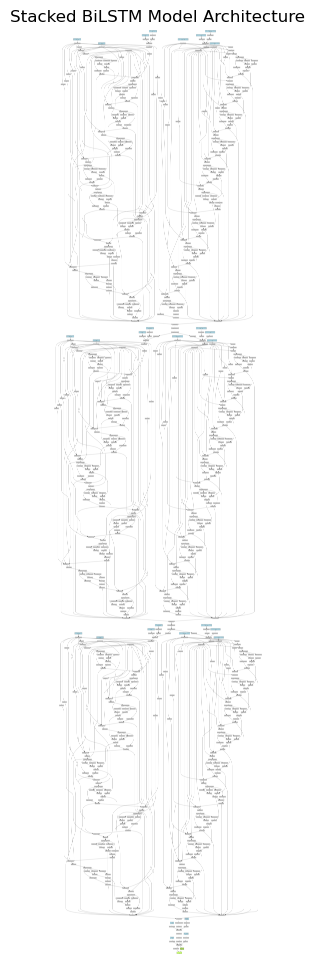

In [72]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchviz import make_dot

# Define the model (same as before)
class StackedBiLSTMModel(nn.Module):
    def __init__(self, input_size, dropout=0.0):
        super(StackedBiLSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=input_size,
                             hidden_size=128,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=128*2,
                             hidden_size=64,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.lstm3 = nn.LSTM(input_size=64*2,
                             hidden_size=32,
                             num_layers=1,
                             bidirectional=True,
                             batch_first=True)
        self.dropout3 = nn.Dropout(dropout)
        self.fc = nn.Linear(32*2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
    
    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out, _ = self.lstm3(out)
        out = self.dropout3(out)
        out = self.fc(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

device = torch.device("cpu")
input_size = 5  # adjust to your actual number of input features
model = StackedBiLSTMModel(input_size=input_size, dropout=0.2).to(device)
model.eval()

# Create a dummy input tensor for visualization
dummy_input = torch.randn(1, 10, input_size).to(device)
output = model(dummy_input)

try:
    graph = make_dot(output, params=dict(model.named_parameters()))
    graph.render("stacked_bilstm_architecture", format="png", cleanup=True)
    print("Model architecture visualization saved as 'stacked_bilstm_architecture.png'.")

    import matplotlib.image as mpimg
    img = mpimg.imread("stacked_bilstm_architecture.png")
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Stacked BiLSTM Model Architecture")
    plt.show()
except Exception as e:
    print("An error occurred while generating the graph:", e)
    print("Make sure Graphviz is installed and the 'dot' executable is available in your system's PATH.")


/var/folders/zf/f48klrhj259_th1d104r4wqw0000gn/T/ipykernel_36275/429880877.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


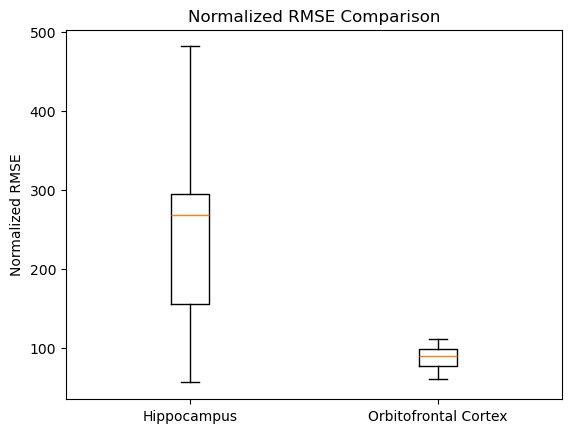

T-test results:
t-statistic = 3.296
p-value = 0.005


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# RMSE values
hippocampus = np.array([171, 284, 56, 276, 260, 482, 329, 107])
orbitofrontal = np.array([111, 61, 96, 108, 87, 79, 91, 70])

# Create a boxplot
data = [hippocampus, orbitofrontal]
labels = ['Hippocampus', 'Orbitofrontal Cortex']

plt.boxplot(data, labels=labels)
plt.title('Normalized RMSE Comparison')
plt.ylabel('Normalized RMSE')
plt.show()

# Perform an independent two-sample t-test
t_stat, p_value = ttest_ind(hippocampus, orbitofrontal)
print("T-test results:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.3f}")
